### 1. Prerequisitos

#### 1.1 Paquetes
Instalación de paquetes requeridos para la ejecución adecuada del Notebook

In [1]:
!pip install --quiet -r requirements.txt

#### 1.2 Librerías
Importación de librerías requeridas para la ejecución adecuada del Notebook

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification,AutoConfig
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tqdm.auto import tqdm
from pathlib import Path
import matplotlib.pyplot as plt

#### 1.3 Variables comúnes
Asignación de variables que son utilizadas en diferentes puntos del Notebook

In [3]:
MODEL_NAME = "google/electra-small-discriminator"
MAX_TOKENS = 512
BATCH_SIZE = 1
EPOCHS = 1
LR = 2e-5
RANDOM_SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE   = 1
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
DATA_PREPR = Path("./data-sources/pre-processed")

### 2. Datos

#### 2.1 Carga de datos
Carga de los datos a ser utilizados para el entrenamiento del modelo, se va a utilizar `google/electra-small-discriminator`

In [4]:
csv_files = sorted(DATA_PREPR.glob("data_chunk_*.csv"))

df_list = []
for f in csv_files:
    df_part = pd.read_csv(f)
    df_list.append(df_part)
data = pd.concat(df_list, ignore_index=True)
print(data.shape)
data.head()

(58963, 2)


,text,pls
0,Background\nThis is an update of a review publ...,0
1,Background\nPolycystic ovary syndrome (PCOS) i...,0
2,Background\nDysmenorrhoea is a common gynaecol...,0
3,Background\nDental caries is a sugar‐dependent...,0
4,Background\nOur March 2021 edition of this rev...,0


#### 2.2 Distribución
Distribución de los datos por cada uno de sus grupos (Texto Cientifico y PLS)

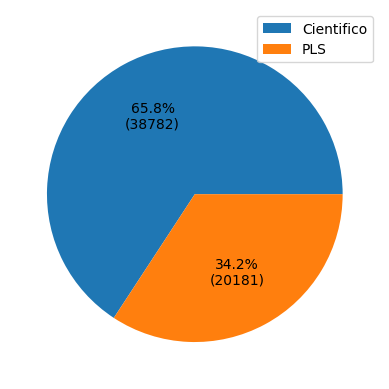

In [5]:
def autopct_format(values):
        def my_format(pct):
            total = sum(values)
            val = int(round(pct*total/100.0))
            return '{:.1f}%\n({v:d})'.format(pct, v=val)
        return my_format

pls_label = {0: 'Cientifico',1: 'PLS'}

df_temp = data.groupby(['pls']).size().to_frame(name='count').reset_index()
df_temp['pls'] = df_temp['pls'].replace(pls_label)

plt.pie(df_temp['count'],autopct=autopct_format(df_temp['count']))
plt.legend(df_temp['pls'])
plt.show()

#### 2.3 División de los datos
Se utiliza el 40% del dataset, y su división de datos en Entrenamiento, Test y Validación, sus porcentajes son 70%, 15% y 15% respectivamente

In [6]:
data, _ = train_test_split(data, test_size=0.4,random_state=RANDOM_SEED,stratify=data['pls'])
df_train, df_temp = train_test_split(data, test_size=0.3,random_state=RANDOM_SEED,stratify=data['pls'])
df_test, df_val = train_test_split(df_temp,test_size=0.5,random_state=RANDOM_SEED,stratify=df_temp['pls'])

print(f'Cantidad de registros dataset entrenamiento: {len(df_train)}, porcentaje {len(df_train)/len(data):.0%}')
print(f'Cantidad de registros dataset validación: {len(df_val)}, porcentaje {len(df_val)/len(data):.0%}')
print(f'Cantidad de registros dataset test: {len(df_test)}, porcentaje {len(df_test)/len(data):.0%}')

Cantidad de registros dataset entrenamiento: 24763, porcentaje 70%
Cantidad de registros dataset validación: 5307, porcentaje 15%
Cantidad de registros dataset test: 5307, porcentaje 15%


### 3. Entrenamiento

#### 3.1 Clases requeridas
Definición de la clases y fnciones requeridas para el entrenamiento del modelo

In [ ]:
config    = AutoConfig.from_pretrained(MODEL_NAME)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

MAX_POS   = int(getattr(config, "max_position_embeddings", 512))
SPECIALS  = tokenizer.num_special_tokens_to_add(pair=False)
CHUNK_LEN = max(8, MAX_POS - SPECIALS)


tokenizer.model_max_length = MAX_POS

In [14]:
def chunk_ids(text: str):
    """
    Convierte texto -> ids (sin especiales) y divide en fragmentos que,
    al añadir especiales y pad, NO superen MAX_POS.
    """
    ids = tokenizer.encode(text, add_special_tokens=False)
    if not ids:
        ids = [tokenizer.pad_token_id]
    return [ids[i:i+CHUNK_LEN] for i in range(0, len(ids), CHUNK_LEN)]

In [8]:
class TextDataset(Dataset):
    def __init__(self, df: pd.DataFrame):
        self.texts  = df["text"].tolist()
        self.labels = df["pls"].tolist()
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        return {"text": str(self.texts[idx]), "label": int(self.labels[idx])}

In [9]:
def collate_fn(batch):
    item = batch[0]

    chunks = chunk_ids(item["text"])
    encoded = [
        tokenizer.prepare_for_model(
            ch,
            truncation=True,
            padding="max_length",
            max_length=MAX_POS,
            return_tensors="pt"
        )
        for ch in chunks
    ]

    input_ids      = torch.cat([e["input_ids"] for e in encoded], dim=0)
    attention_mask = torch.cat([e["attention_mask"] for e in encoded], dim=0)

    if input_ids.dim() == 1:      input_ids = input_ids.unsqueeze(0)
    if attention_mask.dim() == 1: attention_mask = attention_mask.unsqueeze(0)

    label = torch.tensor(item["label"], dtype=torch.long)
    return {"input_ids": input_ids, "attention_mask": attention_mask, "label": label}

In [9]:
class LongTextClassifier(nn.Module):
    def __init__(self, base_model_name: str, num_labels: int = 2):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(base_model_name)
        self.hidden  = int(getattr(self.encoder.config, "hidden_size", 768))
        self.max_pos = int(getattr(self.encoder.config, "max_position_embeddings", 512))
        self.dropout = nn.Dropout(0.2)
        self.classifier = nn.Linear(self.hidden, num_labels)

    def forward(self, input_ids: torch.Tensor, attention_mask: torch.Tensor):
        if input_ids.size(1) > self.max_pos:
            input_ids = input_ids[:, :self.max_pos]
        if attention_mask.size(1) > self.max_pos:
            attention_mask = attention_mask[:, :self.max_pos]

        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]
        doc_embed = cls.mean(dim=0, keepdim=True)
        logits = self.classifier(self.dropout(doc_embed))
        return logits

In [11]:
train_loader = DataLoader(TextDataset(df_train), batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(TextDataset(df_val),   batch_size=1,          shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(TextDataset(df_test),  batch_size=1,          shuffle=False, collate_fn=collate_fn)

In [12]:
model = LongTextClassifier(MODEL_NAME).to(DEVICE)
optimizer = AdamW(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

for epoch in range(EPOCHS):
    model.train()
    loss_sum = 0.0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(DEVICE)
        attn_mask = batch["attention_mask"].to(DEVICE)
        label     = batch["label"].to(DEVICE)

        if input_ids.dim() == 1: input_ids = input_ids.unsqueeze(0)
        if attn_mask.dim() == 1: attn_mask = attn_mask.unsqueeze(0)

        logits = model(input_ids=input_ids, attention_mask=attn_mask)
        loss   = criterion(logits, label.unsqueeze(0))
        loss.backward()
        optimizer.step()
        loss_sum += loss.item()

    print(f"Epoch {epoch+1} | Train Loss: {loss_sum/len(train_loader):.4f}")

    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(DEVICE)
            attn_mask = batch["attention_mask"].to(DEVICE)
            label     = batch["label"].to(DEVICE)

            if input_ids.dim() == 1: input_ids = input_ids.unsqueeze(0)
            if attn_mask.dim() == 1: attn_mask = attn_mask.unsqueeze(0)

            logits = model(input_ids=input_ids, attention_mask=attn_mask)
            preds.append(torch.argmax(logits, dim=1).cpu().item())
            trues.append(label.cpu().item())


Epoch 1:   0%|          | 0/24763 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (526 > 512). Running this sequence through the model will result in indexing errors
You're using a ElectraTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Epoch 1 | Train Loss: 0.0179


In [13]:
model.eval()
preds, trues = [], []
with torch.no_grad():
    for batch in tqdm(val_loader, desc="Testing"):
        input_ids = batch["input_ids"].to(DEVICE)
        attn_mask = batch["attention_mask"].to(DEVICE)
        label     = batch["label"].to(DEVICE)

        if input_ids.dim() == 1: input_ids = input_ids.unsqueeze(0)
        if attn_mask.dim() == 1: attn_mask = attn_mask.unsqueeze(0)

        logits = model(input_ids=input_ids, attention_mask=attn_mask)
        preds.append(torch.argmax(logits, dim=1).cpu().item())
        trues.append(label.cpu().item())


Testing:   0%|          | 0/5307 [00:00<?, ?it/s]

In [14]:
print(classification_report(trues, preds, target_names=["cientifico","PLS"], digits=4))

              precision    recall  f1-score   support

  cientifico     0.9991    0.9983    0.9987      3490
         PLS     0.9967    0.9983    0.9975      1817

    accuracy                         0.9983      5307
   macro avg     0.9979    0.9983    0.9981      5307
weighted avg     0.9983    0.9983    0.9983      5307



In [15]:
torch.save(model.state_dict(), "model_state_dict.pt")

✅ Modelo guardado en model_state_dict.pt


In [10]:
model = LongTextClassifier(MODEL_NAME).to(DEVICE)
state = torch.load('./models/contextual/model_state_dict.pt', map_location=DEVICE)
model.load_state_dict(state)
model.eval()

LongTextClassifier(
  (encoder): ElectraModel(
    (embeddings): ElectraEmbeddings(
      (word_embeddings): Embedding(30522, 128, padding_idx=0)
      (position_embeddings): Embedding(512, 128)
      (token_type_embeddings): Embedding(2, 128)
      (LayerNorm): LayerNorm((128,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (embeddings_project): Linear(in_features=128, out_features=256, bias=True)
    (encoder): ElectraEncoder(
      (layer): ModuleList(
        (0-11): 12 x ElectraLayer(
          (attention): ElectraAttention(
            (self): ElectraSelfAttention(
              (query): Linear(in_features=256, out_features=256, bias=True)
              (key): Linear(in_features=256, out_features=256, bias=True)
              (value): Linear(in_features=256, out_features=256, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): ElectraSelfOutput(
              (dense): Linear(in_featur

In [11]:
id2label = {0: "cientifico", 1: "PLS"}
@torch.no_grad()
def predict_one(text: str):
    chunks = chunk_ids(text)
    encoded = [
        tokenizer.prepare_for_model(
            ch, truncation=True, padding="max_length",
            max_length=MAX_POS, return_tensors="pt"
        )
        for ch in chunks
    ]
    input_ids      = torch.cat([e["input_ids"] for e in encoded], dim=0).to(DEVICE)
    attention_mask = torch.cat([e["attention_mask"] for e in encoded], dim=0).to(DEVICE)

    if input_ids.dim() == 1: input_ids = input_ids.unsqueeze(0)
    if attention_mask.dim() == 1: attention_mask = attention_mask.unsqueeze(0)

    logits = model(input_ids=input_ids, attention_mask=attention_mask)     # (1, 2)
    probs = torch.softmax(logits, dim=-1).squeeze(0).cpu().numpy()         # (2,)
    pred  = int(torch.argmax(logits, dim=-1).item())
    return {"label_id": pred, "label": id2label[pred], "probs": {"cientifico": float(probs[0]), "PLS": float(probs[1])}}


In [15]:
print(df_val['text'].iloc[5])
print(df_val['pls'].iloc[5])
out = predict_one(df_val['text'].iloc[5])
print(out)

Token indices sequence length is longer than the specified maximum sequence length for this model (665 > 512). Running this sequence through the model will result in indexing errors
You're using a ElectraTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


How do different treatments for the vision disorder, convergence insufficiency, compare in effectiveness? 
Why is this question important?Convergence insufficiency is a common vision disorder in which a person's eyes tend to drift outwards when they try to use their eyes together up close. This can cause eye strain, headaches, blurred and double vision. When reading, people with convergence insufficiency frequently lose their place or have to re‐read text. 
There are two main types of treatment for convergence insufficiency: 1) prism‐lensed reading glasses, designed to improve visual comfort, and 2) eye (vision) therapy designed to restore normal visual function and improve visual comfort. 
Different types of vision therapy are prescribed for the treatment of convergence insufficiency that aim to improve the affected person’s convergence ability (the ability of eyes to turn inwards). Treatment can be self‐administered at home using only a pencil (pencil push‐ups) or a computer software